In [ ]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
from pandas.tseries.offsets import MonthEnd
# Payment offsets are days before the target month end.
# The duplicate installation -49 day milestone is intentionally kept as two 25% payments.


In [ ]:
# df=pd.read_excel('../data/ck_dashboard_demo.xlsx', sheet_name='Sheet1')

df_path = "C:\\Users\\CR814QE\\OneDrive - EY\\Desktop\\cd_dashboard_demo.xlsx"
df=pd.read_excel(df_path)

In [ ]:


with open('../data/assumptions.json') as _f:
    ASSUMPTIONS = json.load(_f)
PAYMENT_SCHEDULE = pd.DataFrame(ASSUMPTIONS["payment_schedule"])



def calculate_incurred_capex_by_month(
    df: pd.DataFrame,
    target_month_1: str | pd.Timestamp,
    group_cols=("region_name", "contract_name", "work_package_name"),
):
    """Calculate incurred CAPEX by month and cost type.

    Parameters
    ----------
    df:
        Work-package DataFrame with capex cost-per-socket columns and target_sockets_N
        columns.
    target_month_1:
        Calendar month represented by target_sockets_1, for example "2026-01-01".
        target_sockets_2 is the following month, target_sockets_3 the month after,
        etc.
    group_cols:
        Dimensions to keep in detailed and grouped outputs.

    Returns
    -------
    detail:
        One row per work package, target month, cost type, and scheduled payment.
    monthly_by_type:
        Monthly incurred cost by selected group columns and cost type.
    monthly_pivot:
        Monthly incurred cost with one column per cost type plus total_capex.
    """
    df = df.copy()
    group_cols = list(group_cols)

    target_cols = [col for col in df.columns if re.fullmatch(r"target_sockets_\d+", col)]
    if not target_cols:
        raise ValueError("No target socket columns found. Expected columns like 'target_sockets_1'.")

    target_cols = sorted(target_cols, key=lambda col: int(col.rsplit("_", 1)[1]))
    cost_cols = sorted(PAYMENT_SCHEDULE["cost_column"].unique())
    required_cols = set(group_cols) | set(target_cols) | set(cost_cols)
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    start_month = pd.Timestamp(target_month_1).to_period("M").to_timestamp()

    socket_long = df.melt(
        id_vars=group_cols + cost_cols,
        value_vars=target_cols,
        var_name="target_socket_column",
        value_name="_target_sockets_value",
    )
    socket_long["target_sockets"] = socket_long["_target_sockets_value"].fillna(0)
    socket_long = socket_long.drop(columns="_target_sockets_value")
    socket_long = socket_long[socket_long["target_sockets"] != 0].copy()

    socket_long["target_month_number"] = (
        socket_long["target_socket_column"].str.extract(r"(\d+)$").astype(int)
    )
    socket_long["target_month_end"] = socket_long["target_month_number"].apply(
        lambda month_no: start_month + pd.DateOffset(months=month_no - 1) + MonthEnd(0)
    )

    detail = socket_long.merge(PAYMENT_SCHEDULE, how="cross")
    detail["cost_per_socket"] = 0.0
    for cost_column in cost_cols:
        mask = detail["cost_column"].eq(cost_column)
        detail.loc[mask, "cost_per_socket"] = detail.loc[mask, cost_column]

    detail["incurred_date"] = detail["target_month_end"] + pd.to_timedelta(
        detail["offset_days"],
        unit="D",
    )
    detail["incurred_month"] = detail["incurred_date"].dt.to_period("M").dt.to_timestamp("M")
    detail["incurred_cost"] = (
        detail["target_sockets"] * detail["cost_per_socket"] * detail["payment_pct"]
    )

    detail_cols = group_cols + [
        "target_socket_column",
        "target_month_number",
        "target_month_end",
        "cost_type",
        "offset_days",
        "payment_pct",
        "target_sockets",
        "cost_per_socket",
        "incurred_date",
        "incurred_month",
        "incurred_cost",
    ]
    detail = detail[detail_cols].sort_values(
        group_cols + ["incurred_month", "cost_type", "offset_days"]
    )

    monthly_by_type = (
        detail.groupby(group_cols + ["incurred_month", "cost_type"], as_index=False)[
            "incurred_cost"
        ]
        .sum()
        .sort_values(group_cols + ["incurred_month", "cost_type"])
    )

    monthly_pivot = (
        monthly_by_type.pivot_table(
            index=group_cols + ["incurred_month"],
            columns="cost_type",
            values="incurred_cost",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    for col in ["bom", "connection", "installation"]:
        if col not in monthly_pivot.columns:
            monthly_pivot[col] = 0.0

    monthly_pivot["total_capex"] = monthly_pivot[["bom", "connection", "installation"]].sum(
        axis=1
    )
    monthly_pivot = monthly_pivot[
        group_cols + ["incurred_month", "bom", "connection", "installation", "total_capex"]
    ]

    return detail, monthly_by_type, monthly_pivot

In [119]:
detail, monthly_by_type, monthly_pivot = calculate_incurred_capex_by_month(df, target_month_1)

In [123]:


def plot_bom_incurred_cost_by_month_and_offset(detail: pd.DataFrame,cost_type: str):
    summary = (
        detail
        .groupby(['cost_type', 'offset_days', 'incurred_month'])['incurred_cost']
        .sum()
        .reset_index()
    )

    pivot = (
        summary[summary.cost_type == cost_type]
        .pivot_table(
            index='incurred_month',
            columns='offset_days',
            values='incurred_cost',
            aggfunc='sum',
            fill_value=0
        )
        .sort_index()
    )

    ax = pivot.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    ax.set_title('BOM Incurred Cost by Month and Offset Days')
    ax.set_xlabel('Incurred Month')
    ax.set_ylabel('Incurred Cost')
    ax.legend(title='Offset Days', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


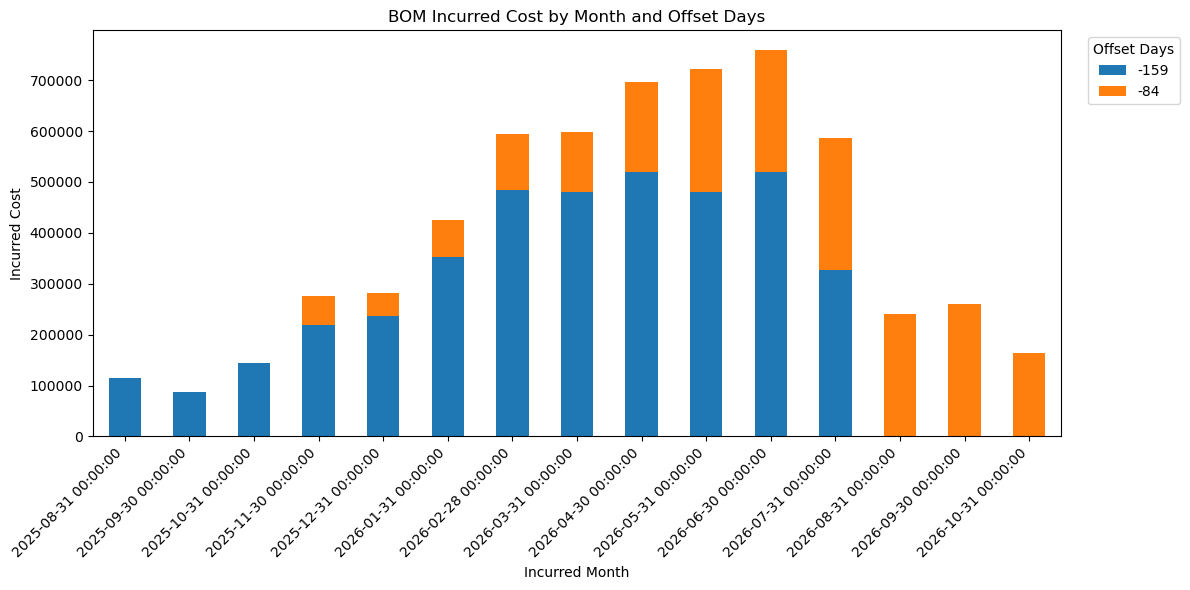

In [126]:
plot_bom_incurred_cost_by_month_and_offset(detail, cost_type="bom")

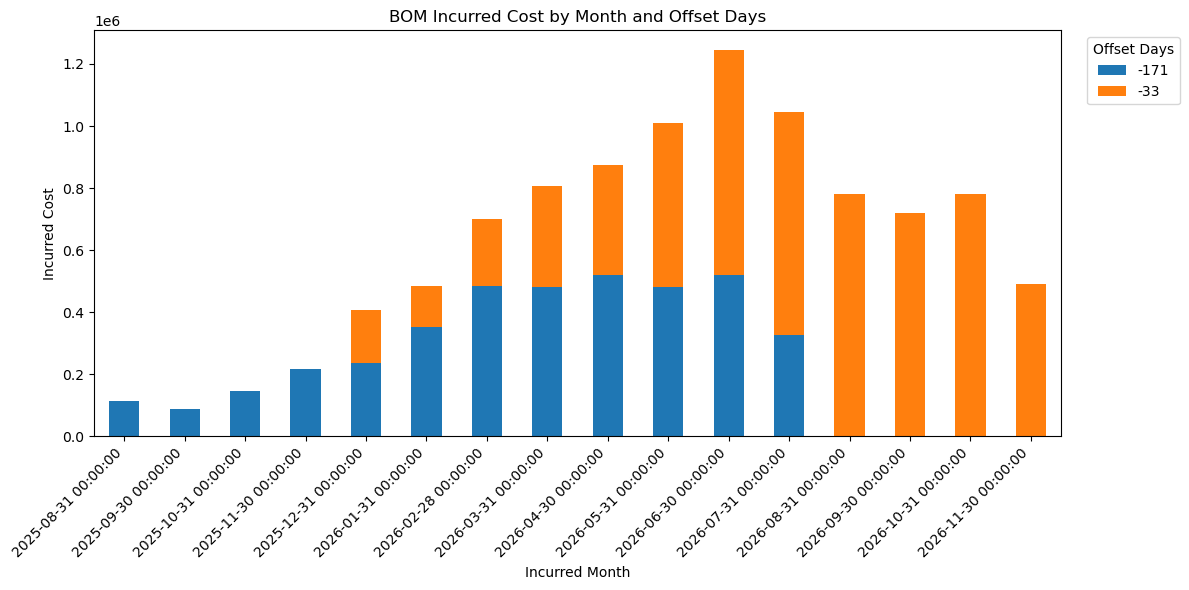

In [127]:
plot_bom_incurred_cost_by_month_and_offset(detail, cost_type="connection")

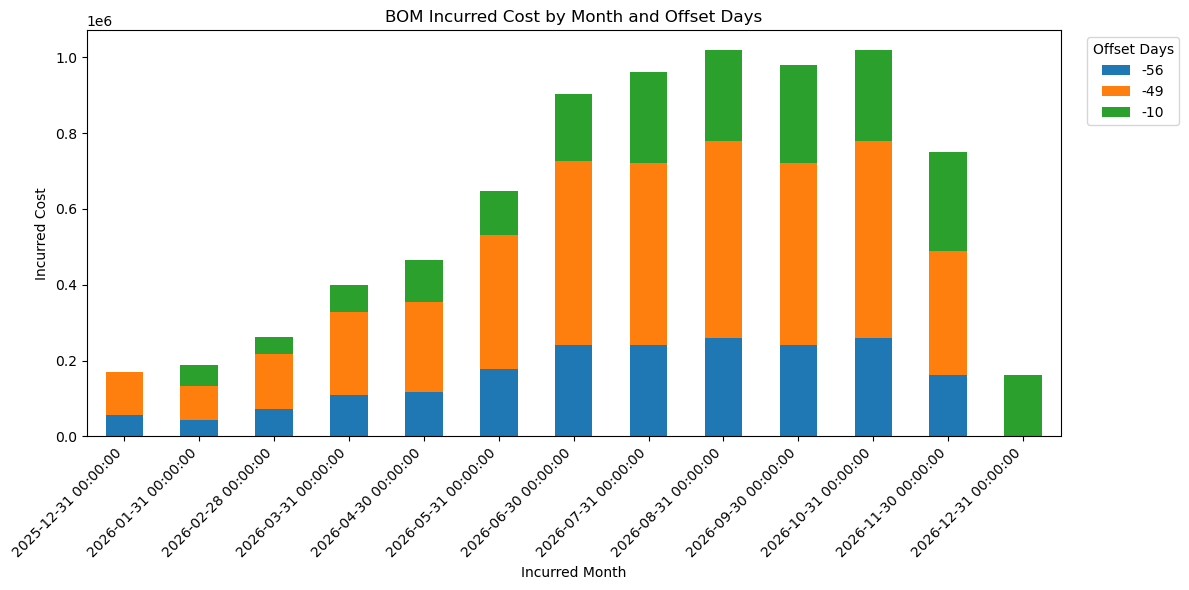

In [128]:
plot_bom_incurred_cost_by_month_and_offset(detail, cost_type="installation")

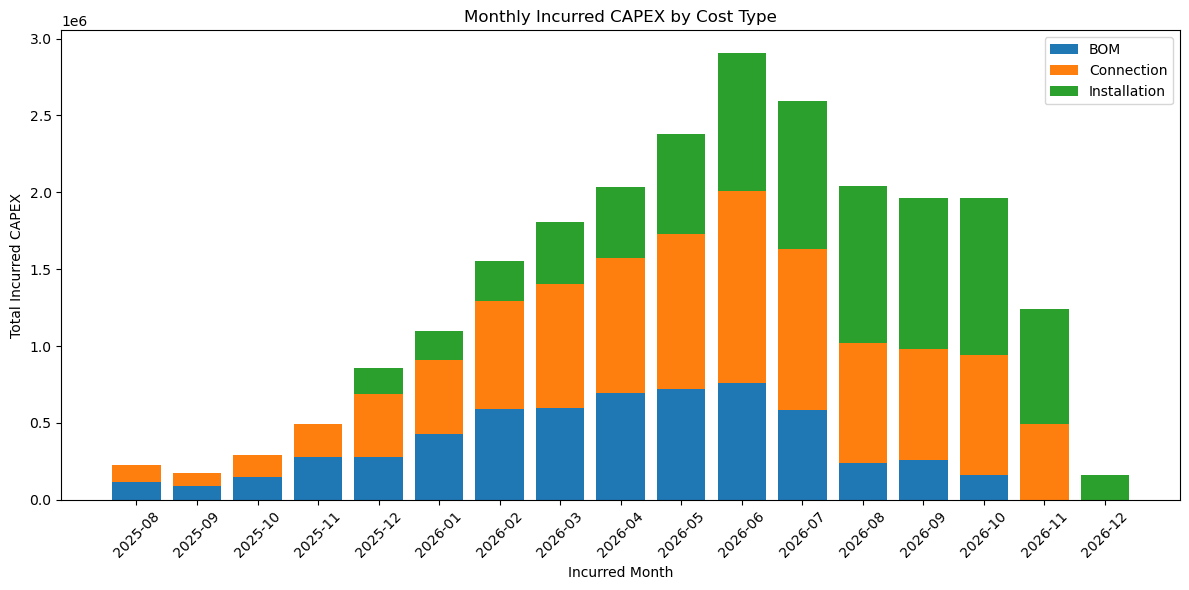

In [125]:
def draw_stacked_bar_chart(monthly_by_type: pd.DataFrame):
    monthly_total_by_cost_type = (
        monthly_by_type.groupby(["incurred_month", "cost_type"], as_index=False)["incurred_cost"]
        .sum()
        .pivot_table(
            index="incurred_month",
            columns="cost_type",
            values="incurred_cost",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    for col in ["bom", "connection", "installation"]:
        if col not in monthly_total_by_cost_type.columns:
            monthly_total_by_cost_type[col] = 0.0

    monthly_total_by_cost_type["total_capex"] = monthly_total_by_cost_type[
        ["bom", "connection", "installation"]
    ].sum(axis=1)
    monthly_total_by_cost_type = monthly_total_by_cost_type[
        ["incurred_month", "bom", "connection", "installation", "total_capex"]
    ]

    monthly_total_by_cost_type = monthly_total_by_cost_type.sort_values("incurred_month")
    plt.figure(figsize=(12, 6))
    plt.bar(
        monthly_total_by_cost_type["incurred_month"].dt.strftime("%Y-%m"),
        monthly_total_by_cost_type["bom"],
        label="BOM",
    )
    plt.bar(
        monthly_total_by_cost_type["incurred_month"].dt.strftime("%Y-%m"),
        monthly_total_by_cost_type["connection"],
        bottom=monthly_total_by_cost_type["bom"],
        label="Connection",
    )
    plt.bar(
        monthly_total_by_cost_type["incurred_month"].dt.strftime("%Y-%m"),
        monthly_total_by_cost_type["installation"],
        bottom=monthly_total_by_cost_type["bom"] + monthly_total_by_cost_type["connection"],
        label="Installation",
    )
    plt.xlabel("Incurred Month")
    plt.ylabel("Total Incurred CAPEX")
    plt.title("Monthly Incurred CAPEX by Cost Type")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

draw_stacked_bar_chart(monthly_by_type)